PART I : PyTorch Intro
====================

a) Introduction to PyTorch
=======================

PyTorch Tensors
---------------


In [1]:
import torch

In [2]:
z = torch.zeros(6, 4)
print(z)
print(z.dtype)

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
torch.float32


In [3]:
i = torch.ones((6, 4), dtype=torch.int16)
print(i)

tensor([[1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1]], dtype=torch.int16)


In [4]:
torch.manual_seed(1729)
r1 = torch.rand(2, 2)
print('A random tensor:')
print(r1)
r2 = torch.rand(2, 2)
print('\nA different random tensor:')
print(r2)
torch.manual_seed(1729)
r3 = torch.rand(2, 2)
print('\nShould match r1:')
print(r3)

A random tensor:
tensor([[0.3126, 0.3791],
        [0.3087, 0.0736]])

A different random tensor:
tensor([[0.4216, 0.0691],
        [0.2332, 0.4047]])

Should match r1:
tensor([[0.3126, 0.3791],
        [0.3087, 0.0736]])


In [5]:
ones = torch.ones(2, 3)
print(ones)

twos = torch.ones(2, 3) * 3 # every element is multiplied by 3
print(twos)

threes = ones + twos
print(threes)
print(threes.shape)

r1 = torch.rand(2, 3)
r2 = torch.rand(3, 2)

tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[3., 3., 3.],
        [3., 3., 3.]])
tensor([[4., 4., 4.],
        [4., 4., 4.]])
torch.Size([2, 3])


In [6]:
r = (torch.rand(2, 2) - 0.5) * 3
print('A random matrix, r:')
print(r)

print('\nAbsolute value of r:')
print(torch.abs(r))

print('\nInverse sine of r:')
print(torch.asin(r))

print('\nDeterminant of r:')
print(torch.det(r))
print('\nSingular value decomposition of r:')
print(torch.svd(r))

print('\nAverage and standard deviation of r:')
print(torch.std_mean(r))
print('\nMaximum value of r:')
print(torch.max(r))

A random matrix, r:
tensor([[ 1.4935, -0.3348],
        [ 0.5787, -0.9890]])

Absolute value of r:
tensor([[1.4935, 0.3348],
        [0.5787, 0.9890]])

Inverse sine of r:
tensor([[    nan, -0.3414],
        [ 0.6171, -1.4221]])

Determinant of r:
tensor(-1.2833)

Singular value decomposition of r:
torch.return_types.svd(
U=tensor([[-0.8353, -0.5497],
        [-0.5497,  0.8353]]),
S=tensor([1.7690, 0.7254]),
V=tensor([[-0.8851, -0.4654],
        [ 0.4654, -0.8851]]))

Average and standard deviation of r:
(tensor(1.0825), tensor(0.1871))

Maximum value of r:
tensor(1.4935)


PyTorch Models
==============

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F  # for activation function

In [9]:
class LeNet(nn.Module):

    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def num_flat_features(self, x):
        size = x.size()[1:]
        num_features = 1
        for s in size:
            num_features *= s
        return num_features

In [10]:
net = LeNet()
print(net)

input = torch.rand(1, 1, 32, 32)
print('\nImage batch shape:')
print(input.shape)

output = net(input)
print('\nRaw output:')
print(output)
print(output.shape)

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Image batch shape:
torch.Size([1, 1, 32, 32])

Raw output:
tensor([[ 0.0898,  0.0318,  0.1485,  0.0301, -0.0085, -0.1135, -0.0296,  0.0164,
          0.0039,  0.0616]], grad_fn=<AddmmBackward0>)
torch.Size([1, 10])


In [11]:
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

In [12]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

100%|██████████| 170M/170M [00:04<00:00, 34.7MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data


In [13]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

 ship   car horse  ship


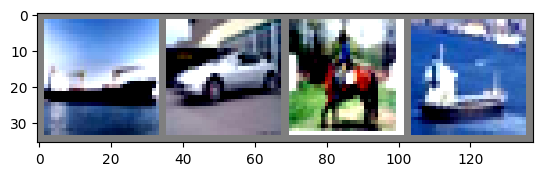

In [14]:
import matplotlib.pyplot as plt
import numpy as np

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(trainloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

Training Your PyTorch Model
===========================


In [15]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [16]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


  cat   cat  deer  frog


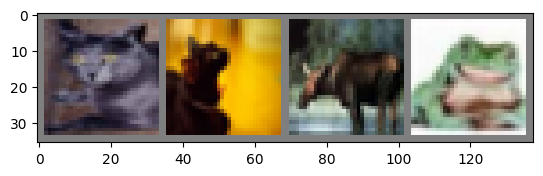

In [17]:
import matplotlib.pyplot as plt
import numpy as np
def imshow(img): # function to display image
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
# printing the labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

In [18]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [27]:
for epoch in range(3):

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 2000 == 1999:
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 1.669
[1,  4000] loss: 1.581
[1,  6000] loss: 1.511
[1,  8000] loss: 1.465
[1, 10000] loss: 1.438
[1, 12000] loss: 1.385
[2,  2000] loss: 1.343
[2,  4000] loss: 1.317
[2,  6000] loss: 1.296
[2,  8000] loss: 1.259
[2, 10000] loss: 1.255
[2, 12000] loss: 1.253
[3,  2000] loss: 1.182
[3,  4000] loss: 1.166
[3,  6000] loss: 1.161
[3,  8000] loss: 1.178
[3, 10000] loss: 1.149
[3, 12000] loss: 1.152
Finished Training


In [28]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 58 %


b. Introduction to PyTorch Tensors
==================================

In [29]:
import torch
import math

Creating Tensors
===============

In [24]:
x = torch.empty(3, 4)
print(type(x))
print(x)

<class 'torch.Tensor'>
tensor([[-1.4560e-13,  4.3985e-41,  3.7923e-34,  0.0000e+00],
        [ 1.0910e-36,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 5.8890e-33,  0.0000e+00,  1.0921e+18,  4.3985e-41]])


In [25]:
zeros = torch.zeros(2, 3)
print(zeros)

ones = torch.ones(2, 3)
print(ones)

torch.manual_seed(1729)
random = torch.rand(2, 3)
print(random)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[0.3126, 0.3791, 0.3087],
        [0.0736, 0.4216, 0.0691]])


Random Tensors and Seeding
==========================

In [25]:
torch.manual_seed(1729)
random1 = torch.rand(2, 3)
print(random1)

random2 = torch.rand(2, 3)
print(random2)

torch.manual_seed(1729)
random3 = torch.rand(2, 3)
print(random3)

random4 = torch.rand(2, 3)
print(random4)

tensor([[0.3126, 0.3791, 0.3087],
        [0.0736, 0.4216, 0.0691]])
tensor([[0.2332, 0.4047, 0.2162],
        [0.9927, 0.4128, 0.5938]])
tensor([[0.3126, 0.3791, 0.3087],
        [0.0736, 0.4216, 0.0691]])
tensor([[0.2332, 0.4047, 0.2162],
        [0.9927, 0.4128, 0.5938]])


Tensor Shapes
============

In [26]:
x = torch.empty(2, 2, 3)
print(x.shape)
print(x)

empty_like_x = torch.empty_like(x)
print(empty_like_x.shape)
print(empty_like_x)

zeros_like_x = torch.zeros_like(x)
print(zeros_like_x.shape)
print(zeros_like_x)

ones_like_x = torch.ones_like(x)
print(ones_like_x.shape)
print(ones_like_x)

rand_like_x = torch.rand_like(x)
print(rand_like_x.shape)
print(rand_like_x)

torch.Size([2, 2, 3])
tensor([[[2.7777e-33, 0.0000e+00, 1.1977e-32],
         [0.0000e+00, 1.1210e-43, 0.0000e+00]],

        [[8.9683e-44, 0.0000e+00, 1.2820e-32],
         [0.0000e+00, 7.5395e+14, 4.3366e-41]]])
torch.Size([2, 2, 3])
tensor([[[2.5760e-33, 0.0000e+00, 1.0610e-32],
         [0.0000e+00, 8.9683e-44, 0.0000e+00]],

        [[1.1210e-43, 0.0000e+00, 1.1958e-32],
         [0.0000e+00, 0.0000e+00, 0.0000e+00]]])
torch.Size([2, 2, 3])
tensor([[[0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.]]])
torch.Size([2, 2, 3])
tensor([[[1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.]]])
torch.Size([2, 2, 3])
tensor([[[0.6128, 0.1519, 0.0453],
         [0.5035, 0.9978, 0.3884]],

        [[0.6929, 0.1703, 0.1384],
         [0.4759, 0.7481, 0.0361]]])


In [27]:
some_constants = torch.tensor([[3.1415926, 2.71828], [1.61803, 0.0072897]])
print(some_constants)

some_integers = torch.tensor((2, 3, 5, 7, 11, 13, 17, 19))
print(some_integers)

more_integers = torch.tensor(((2, 4, 6), [3, 6, 9]))
print(more_integers)

tensor([[3.1416, 2.7183],
        [1.6180, 0.0073]])
tensor([ 2,  3,  5,  7, 11, 13, 17, 19])
tensor([[2, 4, 6],
        [3, 6, 9]])


Tensor Data Types
=================


In [28]:
a = torch.ones((2, 3), dtype=torch.int16)
print(a)

b = torch.rand((2, 3), dtype=torch.float64) * 20.
print(b)

c = b.to(torch.int32)
print(c)

tensor([[1, 1, 1],
        [1, 1, 1]], dtype=torch.int16)
tensor([[ 0.9956,  1.4148,  5.8364],
        [11.2406, 11.2083, 11.6692]], dtype=torch.float64)
tensor([[ 0,  1,  5],
        [11, 11, 11]], dtype=torch.int32)


Math & Logic with PyTorch Tensors
=================================



In [29]:
ones = torch.zeros(2, 2) + 1
twos = torch.ones(2, 2) * 2
threes = (torch.ones(2, 2) * 7 - 1) / 2
fours = twos ** 2
sqrt2s = twos ** 0.5

print(ones)
print(twos)
print(threes)
print(fours)
print(sqrt2s)

tensor([[1., 1.],
        [1., 1.]])
tensor([[2., 2.],
        [2., 2.]])
tensor([[3., 3.],
        [3., 3.]])
tensor([[4., 4.],
        [4., 4.]])
tensor([[1.4142, 1.4142],
        [1.4142, 1.4142]])


In [30]:
powers2 = twos ** torch.tensor([[1, 2], [3, 4]])
print(powers2)

fives = ones + fours
print(fives)

dozens = threes * fours
print(dozens)

tensor([[ 2.,  4.],
        [ 8., 16.]])
tensor([[5., 5.],
        [5., 5.]])
tensor([[12., 12.],
        [12., 12.]])


In Brief: Tensor Broadcasting
=============================


In [31]:
rand = torch.rand(2, 4)
doubled = rand * (torch.ones(1, 4) * 2)

print(rand)
print(doubled)

tensor([[0.6146, 0.5999, 0.5013, 0.9397],
        [0.8656, 0.5207, 0.6865, 0.3614]])
tensor([[1.2291, 1.1998, 1.0026, 1.8793],
        [1.7312, 1.0413, 1.3730, 0.7228]])


In [32]:
a =     torch.ones(4, 3, 2)

b = a * torch.rand(   3, 2)
print(b)

c = a * torch.rand(   3, 1)
print(c)

d = a * torch.rand(   1, 2)
print(d)

tensor([[[0.6493, 0.2633],
         [0.4762, 0.0548],
         [0.2024, 0.5731]],

        [[0.6493, 0.2633],
         [0.4762, 0.0548],
         [0.2024, 0.5731]],

        [[0.6493, 0.2633],
         [0.4762, 0.0548],
         [0.2024, 0.5731]],

        [[0.6493, 0.2633],
         [0.4762, 0.0548],
         [0.2024, 0.5731]]])
tensor([[[0.7191, 0.7191],
         [0.4067, 0.4067],
         [0.7301, 0.7301]],

        [[0.7191, 0.7191],
         [0.4067, 0.4067],
         [0.7301, 0.7301]],

        [[0.7191, 0.7191],
         [0.4067, 0.4067],
         [0.7301, 0.7301]],

        [[0.7191, 0.7191],
         [0.4067, 0.4067],
         [0.7301, 0.7301]]])
tensor([[[0.6276, 0.7357],
         [0.6276, 0.7357],
         [0.6276, 0.7357]],

        [[0.6276, 0.7357],
         [0.6276, 0.7357],
         [0.6276, 0.7357]],

        [[0.6276, 0.7357],
         [0.6276, 0.7357],
         [0.6276, 0.7357]],

        [[0.6276, 0.7357],
         [0.6276, 0.7357],
         [0.6276, 0.7357]]])


More Math with Tensors
======================


In [33]:
a = torch.rand(2, 4) * 2 - 1
print('Common functions:')
print(torch.abs(a))
print(torch.ceil(a))
print(torch.floor(a))
print(torch.clamp(a, -0.5, 0.5))

angles = torch.tensor([0, math.pi / 4, math.pi / 2, 3 * math.pi / 4])
sines = torch.sin(angles)
inverses = torch.asin(sines)
print('\nSine and arcsine:')
print(angles)
print(sines)
print(inverses)

print('\nBitwise XOR:')
b = torch.tensor([1, 5, 11])
c = torch.tensor([2, 7, 10])
print(torch.bitwise_xor(b, c))

print('\nBroadcasted, element-wise equality comparison:')
d = torch.tensor([[1., 2.], [3., 4.]])
e = torch.ones(1, 2)
print(torch.eq(d, e))

print('\nReduction ops:')
print(torch.max(d))
print(torch.max(d).item())
print(torch.mean(d))
print(torch.std(d))
print(torch.prod(d))
print(torch.unique(torch.tensor([1, 2, 1, 2, 1, 2])))

v1 = torch.tensor([1., 0., 0.])
v2 = torch.tensor([0., 1., 0.])
m1 = torch.rand(2, 2)
m2 = torch.tensor([[3., 0.], [0., 3.]])
print('\nVectors & Matrices:')
print(torch.linalg.cross(v2, v1))
print(m1)
m3 = torch.linalg.matmul(m1, m2)
print(m3)
print(torch.linalg.svd(m3))

Common functions:
tensor([[0.9238, 0.5724, 0.0791, 0.2629],
        [0.1986, 0.4439, 0.6434, 0.4776]])
tensor([[-0., -0., 1., -0.],
        [-0., 1., 1., -0.]])
tensor([[-1., -1.,  0., -1.],
        [-1.,  0.,  0., -1.]])
tensor([[-0.5000, -0.5000,  0.0791, -0.2629],
        [-0.1986,  0.4439,  0.5000, -0.4776]])

Sine and arcsine:
tensor([0.0000, 0.7854, 1.5708, 2.3562])
tensor([0.0000, 0.7071, 1.0000, 0.7071])
tensor([0.0000, 0.7854, 1.5708, 0.7854])

Bitwise XOR:
tensor([3, 2, 1])

Broadcasted, element-wise equality comparison:
tensor([[ True, False],
        [False, False]])

Reduction ops:
tensor(4.)
4.0
tensor(2.5000)
tensor(1.2910)
tensor(24.)
tensor([1, 2])

Vectors & Matrices:
tensor([ 0.,  0., -1.])
tensor([[0.7375, 0.8328],
        [0.8444, 0.2941]])
tensor([[2.2125, 2.4985],
        [2.5332, 0.8822]])
torch.return_types.linalg_svd(
U=tensor([[-0.7889, -0.6145],
        [-0.6145,  0.7889]]),
S=tensor([4.1498, 1.0548]),
Vh=tensor([[-0.7957, -0.6056],
        [ 0.6056, -0.7957

Altering Tensors in Place
=========================

In [34]:
a = torch.tensor([0, math.pi / 4, math.pi / 2, 3 * math.pi / 4])
print('a:')
print(a)
print(torch.sin(a))   # creates new tensor in memory
print(a)

b = torch.tensor([0, math.pi / 4, math.pi / 2, 3 * math.pi / 4])
print('\nb:')
print(b)
print(torch.sin_(b))
print(b)              # b is altered

a:
tensor([0.0000, 0.7854, 1.5708, 2.3562])
tensor([0.0000, 0.7071, 1.0000, 0.7071])
tensor([0.0000, 0.7854, 1.5708, 2.3562])

b:
tensor([0.0000, 0.7854, 1.5708, 2.3562])
tensor([0.0000, 0.7071, 1.0000, 0.7071])
tensor([0.0000, 0.7071, 1.0000, 0.7071])


In [35]:
a = torch.ones(2, 2)
b = torch.rand(2, 2)

print('Before:')
print(a)
print(b)
print('\nAfter adding:')
print(a.add_(b))
print(a)
print(b)
print('\nAfter multiplying')
print(b.mul_(b))
print(b)

Before:
tensor([[1., 1.],
        [1., 1.]])
tensor([[0.3788, 0.4567],
        [0.0649, 0.6677]])

After adding:
tensor([[1.3788, 1.4567],
        [1.0649, 1.6677]])
tensor([[1.3788, 1.4567],
        [1.0649, 1.6677]])
tensor([[0.3788, 0.4567],
        [0.0649, 0.6677]])

After multiplying
tensor([[0.1435, 0.2086],
        [0.0042, 0.4459]])
tensor([[0.1435, 0.2086],
        [0.0042, 0.4459]])


In [36]:
a = torch.rand(2, 2)
b = torch.rand(2, 2)
c = torch.zeros(2, 2)
old_id = id(c)

print(c)
d = torch.matmul(a, b, out=c)
print(c)
assert c is d
assert id(c) == old_id
torch.rand(2, 2, out=c)
print(c)
assert id(c) == old_id

tensor([[0., 0.],
        [0., 0.]])
tensor([[0.3653, 0.8699],
        [0.2364, 0.3604]])
tensor([[0.0776, 0.4004],
        [0.9877, 0.0352]])


Copying Tensors
===============


In [37]:
a = torch.ones(2, 2)
b = a

a[0][1] = 561
print(b)

tensor([[  1., 561.],
        [  1.,   1.]])


In [38]:
a = torch.ones(2, 2)
b = a.clone()
assert b is not a
print(torch.eq(a, b))
a[0][1] = 561
print(b)

tensor([[True, True],
        [True, True]])
tensor([[1., 1.],
        [1., 1.]])


In [30]:
a = torch.rand(3, 3, requires_grad=True)
print(a)

b = a.clone()
print(b)

c = a.detach().clone()
print(c)

print(a)

tensor([[0.1384, 0.4759, 0.7481],
        [0.0361, 0.5062, 0.8469],
        [0.2588, 0.2707, 0.4115]], requires_grad=True)
tensor([[0.1384, 0.4759, 0.7481],
        [0.0361, 0.5062, 0.8469],
        [0.2588, 0.2707, 0.4115]], grad_fn=<CloneBackward0>)
tensor([[0.1384, 0.4759, 0.7481],
        [0.0361, 0.5062, 0.8469],
        [0.2588, 0.2707, 0.4115]])
tensor([[0.1384, 0.4759, 0.7481],
        [0.0361, 0.5062, 0.8469],
        [0.2588, 0.2707, 0.4115]], requires_grad=True)


In [31]:
if torch.cuda.is_available():
    print('We have an accelerator!')
else:
    print('Sorry, CPU only.')

We have an accelerator!


In [33]:
if torch.cuda.is_available():
    gpu_rand = torch.rand(3, 4, device='cuda')
    print(gpu_rand)
else:
    print('Sorry, CPU only.')

tensor([[0.0024, 0.6778, 0.2441, 0.6812],
        [0.9678, 0.6866, 0.7877, 0.5457],
        [0.6346, 0.1352, 0.7170, 0.3785]], device='cuda:0')


In [34]:
if torch.cuda.is_available():
    my_device = torch.device('cuda')
else:
    my_device = torch.device('cpu')
print('Device: {}'.format(my_device))

x = torch.rand(2, 2, device=my_device)
print(x)

Device: cuda
tensor([[0.6815, 0.0556],
        [0.0711, 0.4825]], device='cuda:0')


In [35]:
y = torch.rand(2, 2)
y = y.to(my_device)

Manipulating Tensor Shapes
==========================


In [36]:
a = torch.rand(3, 226, 226)
b = a.unsqueeze(0)

print(a.shape)
print(b.shape)

torch.Size([3, 226, 226])
torch.Size([1, 3, 226, 226])


In [37]:
c = torch.rand(1, 1, 1, 1, 1)
print(c)

tensor([[[[[0.7886]]]]])


In [38]:
a = torch.rand(1, 20)
print(a.shape)
print(a)

b = a.squeeze(0)
print(b.shape)
print(b)

c = torch.rand(2, 2)
print(c.shape)

d = c.squeeze(0)
print(d.shape)

torch.Size([1, 20])
tensor([[0.8089, 0.1641, 0.9574, 0.4265, 0.5256, 0.9091, 0.2780, 0.2162, 0.9831,
         0.8699, 0.2427, 0.2078, 0.7600, 0.9164, 0.7021, 0.0459, 0.6895, 0.2177,
         0.6973, 0.8097]])
torch.Size([20])
tensor([0.8089, 0.1641, 0.9574, 0.4265, 0.5256, 0.9091, 0.2780, 0.2162, 0.9831,
        0.8699, 0.2427, 0.2078, 0.7600, 0.9164, 0.7021, 0.0459, 0.6895, 0.2177,
        0.6973, 0.8097])
torch.Size([2, 2])
torch.Size([2, 2])


In [39]:
a = torch.ones(4, 3, 2)
b = torch.rand(   3)
c = b.unsqueeze(1)
print(a * c)

tensor([[[0.8837, 0.8837],
         [0.8394, 0.8394],
         [0.8083, 0.8083]],

        [[0.8837, 0.8837],
         [0.8394, 0.8394],
         [0.8083, 0.8083]],

        [[0.8837, 0.8837],
         [0.8394, 0.8394],
         [0.8083, 0.8083]],

        [[0.8837, 0.8837],
         [0.8394, 0.8394],
         [0.8083, 0.8083]]])


In [40]:
batch_me = torch.rand(3, 226, 226)
print(batch_me.shape)
batch_me.unsqueeze_(0)
print(batch_me.shape)

torch.Size([3, 226, 226])
torch.Size([1, 3, 226, 226])


In [42]:
output3d = torch.rand(6, 20, 20)
print(output3d.shape)
input1d = output3d.reshape(6 * 20 * 20)
print(input1d.shape)
print(torch.reshape(output3d, (6 * 20 * 20,)).shape)

torch.Size([6, 20, 20])
torch.Size([2400])
torch.Size([2400])


NumPy Bridge
============

In [43]:
import numpy as np
numpy_array = np.ones((2, 3))
print(numpy_array)

pytorch_tensor = torch.from_numpy(numpy_array)
print(pytorch_tensor)

[[1. 1. 1.]
 [1. 1. 1.]]
tensor([[1., 1., 1.],
        [1., 1., 1.]], dtype=torch.float64)


In [47]:
pytorch_rand = torch.rand(2, 3)
print(pytorch_rand)

numpy_rand = pytorch_rand.numpy()
print(numpy_rand)

tensor([[0.1247, 0.5777, 0.5106],
        [0.2295, 0.3361, 0.6762]])
[[0.12469602 0.57771045 0.51056874]
 [0.22951084 0.33607054 0.67616856]]


In [48]:
numpy_array[1, 1] = 23
print(pytorch_tensor)

pytorch_rand[1, 1] = 17
print(numpy_rand)

tensor([[ 1.,  1.,  1.],
        [ 1., 23.,  1.]], dtype=torch.float64)
[[ 0.12469602  0.57771045  0.51056874]
 [ 0.22951084 17.          0.67616856]]


c) The Fundamentals of Autograd
============================


A Simple Example
================

In [49]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math

In [50]:
a = torch.linspace(0., 2. * math.pi, steps=25, requires_grad=True)
print(a)

tensor([0.0000, 0.2618, 0.5236, 0.7854, 1.0472, 1.3090, 1.5708, 1.8326, 2.0944,
        2.3562, 2.6180, 2.8798, 3.1416, 3.4034, 3.6652, 3.9270, 4.1888, 4.4506,
        4.7124, 4.9742, 5.2360, 5.4978, 5.7596, 6.0214, 6.2832],
       requires_grad=True)


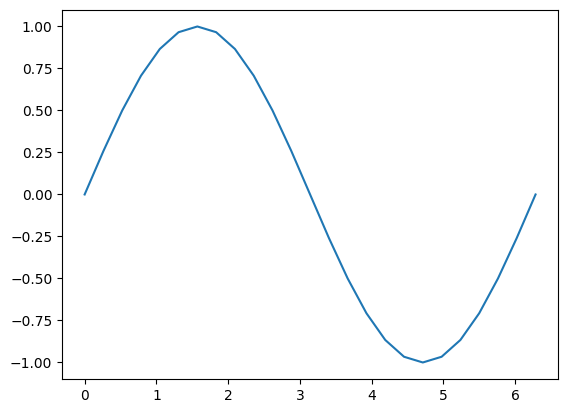

In [51]:
b = torch.sin(a)
plt.plot(a.detach(), b.detach())

In [52]:
print(b)

tensor([ 0.0000e+00,  2.5882e-01,  5.0000e-01,  7.0711e-01,  8.6603e-01,
         9.6593e-01,  1.0000e+00,  9.6593e-01,  8.6603e-01,  7.0711e-01,
         5.0000e-01,  2.5882e-01, -8.7423e-08, -2.5882e-01, -5.0000e-01,
        -7.0711e-01, -8.6603e-01, -9.6593e-01, -1.0000e+00, -9.6593e-01,
        -8.6603e-01, -7.0711e-01, -5.0000e-01, -2.5882e-01,  1.7485e-07],
       grad_fn=<SinBackward0>)


In [53]:
c = 2 * b
print(c)

d = c + 1
print(d)

tensor([ 0.0000e+00,  5.1764e-01,  1.0000e+00,  1.4142e+00,  1.7321e+00,
         1.9319e+00,  2.0000e+00,  1.9319e+00,  1.7321e+00,  1.4142e+00,
         1.0000e+00,  5.1764e-01, -1.7485e-07, -5.1764e-01, -1.0000e+00,
        -1.4142e+00, -1.7321e+00, -1.9319e+00, -2.0000e+00, -1.9319e+00,
        -1.7321e+00, -1.4142e+00, -1.0000e+00, -5.1764e-01,  3.4969e-07],
       grad_fn=<MulBackward0>)
tensor([ 1.0000e+00,  1.5176e+00,  2.0000e+00,  2.4142e+00,  2.7321e+00,
         2.9319e+00,  3.0000e+00,  2.9319e+00,  2.7321e+00,  2.4142e+00,
         2.0000e+00,  1.5176e+00,  1.0000e+00,  4.8236e-01, -3.5763e-07,
        -4.1421e-01, -7.3205e-01, -9.3185e-01, -1.0000e+00, -9.3185e-01,
        -7.3205e-01, -4.1421e-01,  4.7684e-07,  4.8236e-01,  1.0000e+00],
       grad_fn=<AddBackward0>)


In [54]:
out = d.sum()
print(out)

tensor(25., grad_fn=<SumBackward0>)


In [55]:
print('d:')
print(d.grad_fn)
print(d.grad_fn.next_functions)
print(d.grad_fn.next_functions[0][0].next_functions)
print(d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions)
print(d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions[0][0].next_functions)
print('\nc:')
print(c.grad_fn)
print('\nb:')
print(b.grad_fn)
print('\na:')
print(a.grad_fn)

d:
((<MulBackward0 object at 0x7a9ca0077940>, 0), (None, 0))
((<SinBackward0 object at 0x7a9ca0075000>, 0), (None, 0))
((<AccumulateGrad object at 0x7a9ca0075330>, 0),)
()

c:

b:

a:
None


tensor([ 2.0000e+00,  1.9319e+00,  1.7321e+00,  1.4142e+00,  1.0000e+00,
         5.1764e-01, -8.7423e-08, -5.1764e-01, -1.0000e+00, -1.4142e+00,
        -1.7321e+00, -1.9319e+00, -2.0000e+00, -1.9319e+00, -1.7321e+00,
        -1.4142e+00, -1.0000e+00, -5.1764e-01,  2.3850e-08,  5.1764e-01,
         1.0000e+00,  1.4142e+00,  1.7321e+00,  1.9319e+00,  2.0000e+00])


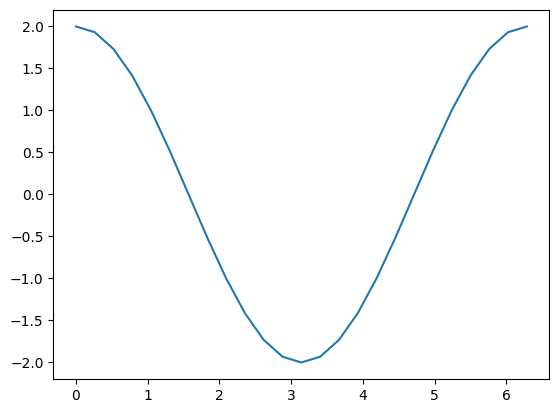

In [56]:
out.backward()
print(a.grad)
plt.plot(a.detach(), a.grad.detach())


Autograd in Training
====================

In [57]:
BATCH_SIZE = 16
DIM_IN = 1000
HIDDEN_SIZE = 100
DIM_OUT = 10

class TinyModel(torch.nn.Module):

    def __init__(self):
        super(TinyModel, self).__init__()

        self.layer1 = torch.nn.Linear(DIM_IN, HIDDEN_SIZE)
        self.relu = torch.nn.ReLU()
        self.layer2 = torch.nn.Linear(HIDDEN_SIZE, DIM_OUT)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

some_input = torch.randn(BATCH_SIZE, DIM_IN, requires_grad=False)
ideal_output = torch.randn(BATCH_SIZE, DIM_OUT, requires_grad=False)

model = TinyModel()

In [58]:
print(model.layer2.weight[0][0:10]) # just a small slice
print(model.layer2.weight.grad)

tensor([ 0.0432, -0.0912,  0.0140,  0.0436, -0.0619, -0.0357, -0.0207, -0.0166,
         0.0448, -0.0124], grad_fn=<SliceBackward0>)
None


In [59]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

prediction = model(some_input)

loss = (ideal_output - prediction).pow(2).sum()
print(loss)

tensor(165.9154, grad_fn=<SumBackward0>)


In [60]:
loss.backward()
print(model.layer2.weight[0][0:10])
print(model.layer2.weight.grad[0][0:10])

tensor([ 0.0432, -0.0912,  0.0140,  0.0436, -0.0619, -0.0357, -0.0207, -0.0166,
         0.0448, -0.0124], grad_fn=<SliceBackward0>)
tensor([ 3.0633, -8.5822, -0.1889,  0.4718, -4.3404, -3.0070, -2.6880, -0.0185,
         0.3259, -2.0224])


In [61]:
optimizer.step()
print(model.layer2.weight[0][0:10])
print(model.layer2.weight.grad[0][0:10])

tensor([ 0.0402, -0.0826,  0.0142,  0.0431, -0.0576, -0.0327, -0.0180, -0.0166,
         0.0444, -0.0104], grad_fn=<SliceBackward0>)
tensor([ 3.0633, -8.5822, -0.1889,  0.4718, -4.3404, -3.0070, -2.6880, -0.0185,
         0.3259, -2.0224])


In [62]:
print(model.layer2.weight.grad[0][0:10])

for i in range(0, 5):
    prediction = model(some_input)
    loss = (ideal_output - prediction).pow(2).sum()
    loss.backward()

print(model.layer2.weight.grad[0][0:10])

optimizer.zero_grad(set_to_none=False)

print(model.layer2.weight.grad[0][0:10])

tensor([ 3.0633, -8.5822, -0.1889,  0.4718, -4.3404, -3.0070, -2.6880, -0.0185,
         0.3259, -2.0224])
tensor([ 14.0606, -29.4279,  -2.0159, -16.6787,  -7.9671,   2.3832,  -7.0161,
         -3.7514,   5.6269,  -6.1614])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


Turning Autograd Off and On
===========================


In [63]:
a = torch.ones(2, 3, requires_grad=True)
print(a)

b1 = 2 * a
print(b1)

a.requires_grad = False
b2 = 2 * a
print(b2)

tensor([[1., 1., 1.],
        [1., 1., 1.]], requires_grad=True)
tensor([[2., 2., 2.],
        [2., 2., 2.]], grad_fn=<MulBackward0>)
tensor([[2., 2., 2.],
        [2., 2., 2.]])


In [64]:
a = torch.ones(2, 3, requires_grad=True) * 2
b = torch.ones(2, 3, requires_grad=True) * 3

c1 = a + b
print(c1)

with torch.no_grad():
    c2 = a + b

print(c2)

c3 = a * b
print(c3)

tensor([[5., 5., 5.],
        [5., 5., 5.]], grad_fn=<AddBackward0>)
tensor([[5., 5., 5.],
        [5., 5., 5.]])
tensor([[6., 6., 6.],
        [6., 6., 6.]], grad_fn=<MulBackward0>)


In [65]:
def add_tensors1(x, y):
    return x + y

@torch.no_grad()
def add_tensors2(x, y):
    return x + y


a = torch.ones(2, 3, requires_grad=True) * 2
b = torch.ones(2, 3, requires_grad=True) * 3

c1 = add_tensors1(a, b)
print(c1)

c2 = add_tensors2(a, b)
print(c2)

tensor([[5., 5., 5.],
        [5., 5., 5.]], grad_fn=<AddBackward0>)
tensor([[5., 5., 5.],
        [5., 5., 5.]])


In [66]:
x = torch.rand(5, requires_grad=True)
y = x.detach()

print(x)
print(y)

tensor([0.6240, 0.6150, 0.5207, 0.0186, 0.7636], requires_grad=True)
tensor([0.6240, 0.6150, 0.5207, 0.0186, 0.7636])


Autograd and In-place Operations
================================

Autograd Profiler
=================


In [67]:
device = torch.device('cpu')
run_on_gpu = False
if torch.cuda.is_available():
    device = torch.device('cuda')
    run_on_gpu = True

x = torch.randn(2, 3, requires_grad=True)
y = torch.rand(2, 3, requires_grad=True)
z = torch.ones(2, 3, requires_grad=True)

with torch.autograd.profiler.profile(use_cuda=run_on_gpu) as prf:
    for _ in range(1000):
        z = (z / x) * y

print(prf.key_averages().table(sort_by='self_cpu_time_total'))

<ipython-input-67-cb25284932df>:11: FutureWarning: The attribute `use_cuda` will be deprecated soon, please use ``use_device = 'cuda'`` instead.
  with torch.autograd.profiler.profile(use_cuda=run_on_gpu) as prf:


-------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                     Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
          cudaEventRecord        44.36%       7.126ms        44.36%       7.126ms       1.781us       0.000us         0.00%       0.000us       0.000us          4000  
                aten::div        28.13%       4.518ms        28.13%       4.518ms       4.518us       8.451ms        50.54%       8.451ms       8.451us          1000  
                aten::mul        27.44%       4.408ms        27.44%       4.408ms       4.408us       8.270ms        49.46%       8.270ms       8.270us        

Advanced Topic: More Autograd Detail and the High-Level API
===========================================================


In [68]:
x = torch.randn(3, requires_grad=True)

y = x * 2
while y.data.norm() < 1000:
    y = y * 2

print(y)

tensor([  302.6257, -1046.5419,  1288.3206], grad_fn=<MulBackward0>)


In [69]:
v = torch.tensor([0.1, 1.0, 0.0001], dtype=torch.float)
y.backward(v)
print(x.grad)

tensor([1.0240e+02, 1.0240e+03, 1.0240e-01])


The High-Level API
==================

In [72]:
def exp_adder(x, y):
    return 2 * x.exp() + 3 * y
inputs = (torch.rand(1), torch.rand(1))
print(inputs)
torch.autograd.functional.jacobian(exp_adder, inputs)

(tensor([0.6321]), tensor([0.8097]))


(tensor([[3.7632]]), tensor([[3.]]))

In [ ]:
inputs = (torch.rand(3), torch.rand(3)) # arguments for the function
print(inputs)
torch.autograd.functional.jacobian(exp_adder, inputs)

In [73]:
def do_some_doubling(x):
    y = x * 2
    while y.data.norm() < 1000:
        y = y * 2
    return y

inputs = torch.randn(3)
my_gradients = torch.tensor([0.1, 1.0, 0.0001])
torch.autograd.functional.vjp(do_some_doubling, inputs, v=my_gradients)

(tensor([ 864.7858, -773.7997, -190.6635]),
 tensor([1.0240e+02, 1.0240e+03, 1.0240e-01]))

d) Building Models with PyTorch
============================


In [76]:
class TinyModel(torch.nn.Module):

    def __init__(self):
        super(TinyModel, self).__init__()

        self.linear1 = torch.nn.Linear(100, 200)
        self.activation = torch.nn.ReLU()
        self.linear2 = torch.nn.Linear(200, 10)
        self.softmax = torch.nn.Softmax()

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        x = self.softmax(x)
        return x

tinymodel = TinyModel()

print('The model:')
print(tinymodel)

print('\n\nJust one layer:')
print(tinymodel.linear2)

print('\n\nModel params:')
for param in tinymodel.parameters():
    print(param)

print('\n\nLayer params:')
for param in tinymodel.linear2.parameters():
    print(param)

The model:
TinyModel(
  (linear1): Linear(in_features=100, out_features=200, bias=True)
  (activation): ReLU()
  (linear2): Linear(in_features=200, out_features=10, bias=True)
  (softmax): Softmax(dim=None)
)


Just one layer:
Linear(in_features=200, out_features=10, bias=True)


Model params:
Parameter containing:
tensor([[ 0.0136, -0.0270, -0.0930,  ...,  0.0455,  0.0901, -0.0959],
        [ 0.0855,  0.0796,  0.0562,  ..., -0.0766, -0.0257,  0.0555],
        [ 0.0976, -0.0701,  0.0671,  ..., -0.0954, -0.0205,  0.0630],
        ...,
        [ 0.0738,  0.0832,  0.0193,  ..., -0.0751, -0.0844,  0.0349],
        [-0.0799,  0.0958,  0.0608,  ...,  0.0581, -0.0537, -0.0267],
        [ 0.0522, -0.0413,  0.0009,  ..., -0.0275, -0.0528,  0.0528]],
       requires_grad=True)
Parameter containing:
tensor([ 0.0559,  0.0669,  0.0112,  0.0592, -0.0936, -0.0465,  0.0842, -0.0384,
        -0.0411,  0.0767,  0.0586,  0.0064, -0.0153, -0.0439,  0.0266, -0.0381,
        -0.0113, -0.0391, -0.0007, -0.00

Common Layer Types
==================
Linear Layers
-------------

In [77]:
lin = torch.nn.Linear(3, 2)
x = torch.rand(1, 3)
print('Input:')
print(x)

print('\n\nWeight and Bias parameters:')
for param in lin.parameters():
    print(param)

y = lin(x)
print('\n\nOutput:')
print(y)

Input:
tensor([[0.8162, 0.8748, 0.7490]])


Weight and Bias parameters:
Parameter containing:
tensor([[ 0.4845, -0.2468, -0.3587],
        [-0.2100,  0.4645,  0.2635]], requires_grad=True)
Parameter containing:
tensor([0.1542, 0.1944], requires_grad=True)


Output:
tensor([[0.0651, 0.6267]], grad_fn=<AddmmBackward0>)


Convolutional Layers
====================

In [81]:
import torch.functional as F


class LeNet(torch.nn.Module):

    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 6, 5)
        self.conv2 = torch.nn.Conv2d(6, 16, 3)
        self.fc1 = torch.nn.Linear(16 * 6 * 6, 120)
        self.fc2 = torch.nn.Linear(120, 84)
        self.fc3 = torch.nn.Linear(84, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    def num_flat_features(self, x):
        size = x.size()[1:]
        num_features = 1
        for s in size:
            num_features *= s
        return num_features

Recurrent Layers
================

In [82]:
class LSTMTagger(torch.nn.Module):

    def __init__(self, embedding_dim, hidden_dim, vocab_size, tagset_size):
        super(LSTMTagger, self).__init__()
        self.hidden_dim = hidden_dim

        self.word_embeddings = torch.nn.Embedding(vocab_size, embedding_dim)

        # The LSTM takes word embeddings as inputs, and outputs hidden states
        # with dimensionality hidden_dim.
        self.lstm = torch.nn.LSTM(embedding_dim, hidden_dim)

        # The linear layer that maps from hidden state space to tag space
        self.hidden2tag = torch.nn.Linear(hidden_dim, tagset_size)

    def forward(self, sentence):
        embeds = self.word_embeddings(sentence)
        lstm_out, _ = self.lstm(embeds.view(len(sentence), 1, -1))
        tag_space = self.hidden2tag(lstm_out.view(len(sentence), -1))
        tag_scores = F.log_softmax(tag_space, dim=1)
        return tag_scores

Transformers
============
Data Manipulation Layers
========================

In [84]:
my_tensor = torch.rand(1, 6, 6)
print(my_tensor)
maxpool_layer = torch.nn.MaxPool2d(3)
print(maxpool_layer(my_tensor))

tensor([[[0.4050, 0.6431, 0.5497, 0.6720, 0.9872, 0.8267],
         [0.9011, 0.2938, 0.7262, 0.5881, 0.3201, 0.6707],
         [0.6644, 0.9665, 0.1076, 0.6274, 0.7101, 0.0348],
         [0.5376, 0.7298, 0.4973, 0.7346, 0.4472, 0.5395],
         [0.1045, 0.0024, 0.9072, 0.7368, 0.4110, 0.4113],
         [0.2501, 0.3182, 0.7079, 0.6851, 0.5020, 0.0015]]])
tensor([[[0.9665, 0.9872],
         [0.9072, 0.7368]]])


In [85]:
my_tensor = torch.rand(1, 4, 4) * 20 + 5
print(my_tensor)
print(my_tensor.mean())
norm_layer = torch.nn.BatchNorm1d(4)
normed_tensor = norm_layer(my_tensor)
print(normed_tensor)

print(normed_tensor.mean())

tensor([[[20.1996, 15.7384,  8.5474, 15.7387],
         [ 7.4950,  8.8011,  6.7373, 12.3233],
         [10.7160, 20.5353,  5.6154, 22.8750],
         [12.9127,  7.7254, 15.9605, 17.4693]]])
tensor(13.0869)
tensor([[[ 1.2317,  0.1634, -1.5586,  0.1635],
         [-0.6273, -0.0178, -0.9809,  1.6260],
         [-0.5981,  0.7938, -1.3212,  1.1255],
         [-0.1622, -1.5548,  0.6560,  1.0611]]],
       grad_fn=<NativeBatchNormBackward0>)
tensor(0., grad_fn=<MeanBackward0>)


In [87]:
my_tensor = torch.rand(1, 4, 4)
dropout = torch.nn.Dropout(p=0.4)
print(dropout(my_tensor))
print(dropout(my_tensor))

tensor([[[1.2917, 1.5262, 0.3649, 1.1835],
         [1.4808, 0.3318, 0.3092, 1.1854],
         [0.6697, 0.9478, 0.0000, 0.0000],
         [0.0000, 1.5344, 0.0000, 0.0000]]])
tensor([[[1.2917, 1.5262, 0.0000, 1.1835],
         [0.0000, 0.0000, 0.3092, 1.1854],
         [0.6697, 0.9478, 0.8381, 0.4699],
         [1.2088, 0.0000, 0.0000, 0.0000]]])


e) PyTorch TensorBoard Support
===========================


In [89]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.tensorboard import SummaryWriter


Showing Images in TensorBoard
=============================

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.0MB/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 6.14MB/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



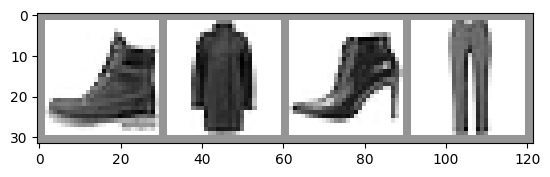

In [90]:

transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])
training_set = torchvision.datasets.FashionMNIST('./data',
    download=True,
    train=True,
    transform=transform)
validation_set = torchvision.datasets.FashionMNIST('./data',
    download=True,
    train=False,
    transform=transform)

training_loader = torch.utils.data.DataLoader(training_set,
                                              batch_size=4,
                                              shuffle=True,
                                              num_workers=2)

validation_loader = torch.utils.data.DataLoader(validation_set,
                                                batch_size=4,
                                                shuffle=False,
                                                num_workers=2)

# Class labels
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(training_loader)
images, labels = next(dataiter)
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)

In [95]:
writer = SummaryWriter('runs/fashion_mnist_experiment_1')
writer.add_image('Four Fashion-MNIST Images', img_grid)
writer.flush()

# To view, start TensorBoard on the command line with:
#   tensorboard --logdir=runs
# ...and open a browser tab to http://localhost:6006/

Graphing Scalars to Visualize Training
======================================

In [97]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [98]:
print(len(validation_loader))
for epoch in range(1):
    running_loss = 0.0
    for i, data in enumerate(training_loader, 0):  #training loop
        inputs, labels = data
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 1000 == 999:
            print('Batch {}'.format(i + 1))
            running_vloss = 0.0
            net.train(False) # Switch to evaluation mode
            for j, vdata in enumerate(validation_loader, 0):
                vinputs, vlabels = vdata
                voutputs = net(vinputs)
                vloss = criterion(voutputs, vlabels)
                running_vloss += vloss.item()
            net.train(True) # Switching back to training mode

            avg_loss = running_loss / 1000
            avg_vloss = running_vloss / len(validation_loader)
            writer.add_scalars('Training vs. Validation Loss',
                            { 'Training' : avg_loss, 'Validation' : avg_vloss },
                            epoch * len(training_loader) + i)

            running_loss = 0.0
print('Finished Training')

writer.flush()

2500
Batch 1000
Batch 2000
Batch 3000
Batch 4000
Batch 5000
Batch 6000
Batch 7000
Batch 8000
Batch 9000
Batch 10000
Batch 11000
Batch 12000
Batch 13000
Batch 14000
Batch 15000
Finished Training


Visualizing Your Model
======================

In [99]:
# grab single mini-batch of images
dataiter = iter(training_loader)
images, labels = next(dataiter)
writer.add_graph(net, images)
writer.flush()

Visualizing Your Dataset with Embeddings
========================================


In [100]:
def select_n_random(data, labels, n=100):
    assert len(data) == len(labels)

    perm = torch.randperm(len(data))
    return data[perm][:n], labels[perm][:n]

images, labels = select_n_random(training_set.data, training_set.targets)

class_labels = [classes[label] for label in labels]
features = images.view(-1, 28 * 28)
writer.add_embedding(features,
                    metadata=class_labels,
                    label_img=images.unsqueeze(1))
writer.flush()
writer.close()

f) Training with PyTorch
=====================

In [101]:
import torch
import torchvision
import torchvision.transforms as transforms

# PyTorch TensorBoard support
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])
# Creates dataset for training & validation
training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
validation_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform, download=True)

# Creates data loaders for our datasets
training_loader = torch.utils.data.DataLoader(training_set, batch_size=4, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=4, shuffle=False)
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')
print('Training set has {} instances'.format(len(training_set)))
print('Validation set has {} instances'.format(len(validation_set)))

Training set has 60000 instances
Validation set has 10000 instances


Shirt  Trouser  Ankle Boot  Sneaker


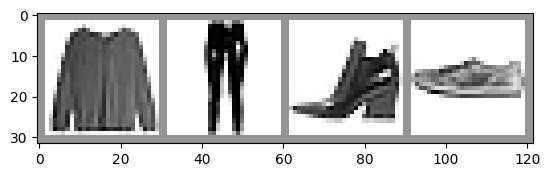

In [102]:
import matplotlib.pyplot as plt
import numpy as np
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(training_loader)
images, labels = next(dataiter)
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)
print('  '.join(classes[labels[j]] for j in range(4)))

The Model
=========

In [103]:
import torch.nn as nn
import torch.nn.functional as F
class GarmentClassifier(nn.Module):
    def __init__(self):
        super(GarmentClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
model = GarmentClassifier()

Loss Function
=============


In [104]:
loss_fn = torch.nn.CrossEntropyLoss()
dummy_outputs = torch.rand(4, 10)
# Represents the correct class among the 10 being tested
dummy_labels = torch.tensor([1, 5, 3, 7])
print(dummy_outputs)
print(dummy_labels)
loss = loss_fn(dummy_outputs, dummy_labels)
print('Total loss for this batch: {}'.format(loss.item()))

tensor([[0.4879, 0.2930, 0.3081, 0.3142, 0.2281, 0.3400, 0.5015, 0.9427, 0.9816,
         0.4965],
        [0.0305, 0.1671, 0.6025, 0.9624, 0.3757, 0.7796, 0.4408, 0.0164, 0.1189,
         0.4426],
        [0.0079, 0.6344, 0.0425, 0.3002, 0.6387, 0.0387, 0.2037, 0.5143, 0.6651,
         0.3267],
        [0.8100, 0.8250, 0.6322, 0.8933, 0.4073, 0.1569, 0.7723, 0.6007, 0.5712,
         0.0170]])
tensor([1, 5, 3, 7])
Total loss for this batch: 2.293713331222534


Optimizer
=========


In [105]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

The Training Loop
=================


In [106]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.

    for i, data in enumerate(training_loader):
        # Every data instance is an input + label pair
        inputs, labels = data
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(training_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.

    return last_loss

Per-Epoch Activity
==================

In [107]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0
EPOCHS = 4
best_vloss = 1_000_000.
for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))
    model.train(True)
    avg_loss = train_one_epoch(epoch_number, writer)
    running_vloss = 0.0
    model.eval()

    with torch.no_grad():
        for i, vdata in enumerate(validation_loader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs)
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))

    writer.add_scalars('Training vs. Validation Loss',
                    { 'Training' : avg_loss, 'Validation' : avg_vloss },
                    epoch_number + 1)
    writer.flush()

    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        torch.save(model.state_dict(), model_path)
    epoch_number += 1

EPOCH 1:
  batch 1000 loss: 1.7955968375355005
  batch 2000 loss: 0.8875556206256151
  batch 3000 loss: 0.709551970904693
  batch 4000 loss: 0.6656332226842642
  batch 5000 loss: 0.6124141392842867
  batch 6000 loss: 0.6129390098163858
  batch 7000 loss: 0.6017001645735
  batch 8000 loss: 0.5421902124579064
  batch 9000 loss: 0.5254351024196949
  batch 10000 loss: 0.507071785565
  batch 11000 loss: 0.5088120407273528
  batch 12000 loss: 0.49234178234729914
  batch 13000 loss: 0.4624865979703609
  batch 14000 loss: 0.4716681088309269
  batch 15000 loss: 0.44106156108732103
LOSS train 0.44106156108732103 valid 0.5052930116653442
EPOCH 2:
  batch 1000 loss: 0.4416152078163577
  batch 2000 loss: 0.44659565907836807
  batch 3000 loss: 0.4218924134708941
  batch 4000 loss: 0.4269225222673267
  batch 5000 loss: 0.4001502863921341
  batch 6000 loss: 0.3848820980390592
  batch 7000 loss: 0.40592341740900884
  batch 8000 loss: 0.40648691174125995
  batch 9000 loss: 0.400045058049378
  batch 1000

In [108]:
"References: https://pytorch.org/tutorials/beginner/introyt/introyt_index.html"

'References: https://pytorch.org/tutorials/beginner/introyt/introyt_index.html'